In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

cal_data = pd.read_csv('calories.csv')
cal_data.head()



,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [2]:
exercise =pd.read_csv('exercise.csv')
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [17]:
#concatenating both the dataframes based on their User_ID
calorie_data = pd.concat([exercise, cal_data['Calories']], axis=1)
calorie_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [18]:
#encode the Gender column
calorie_data.replace({'Gender':{'male':0,'female':1}}, inplace=True)
calorie_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


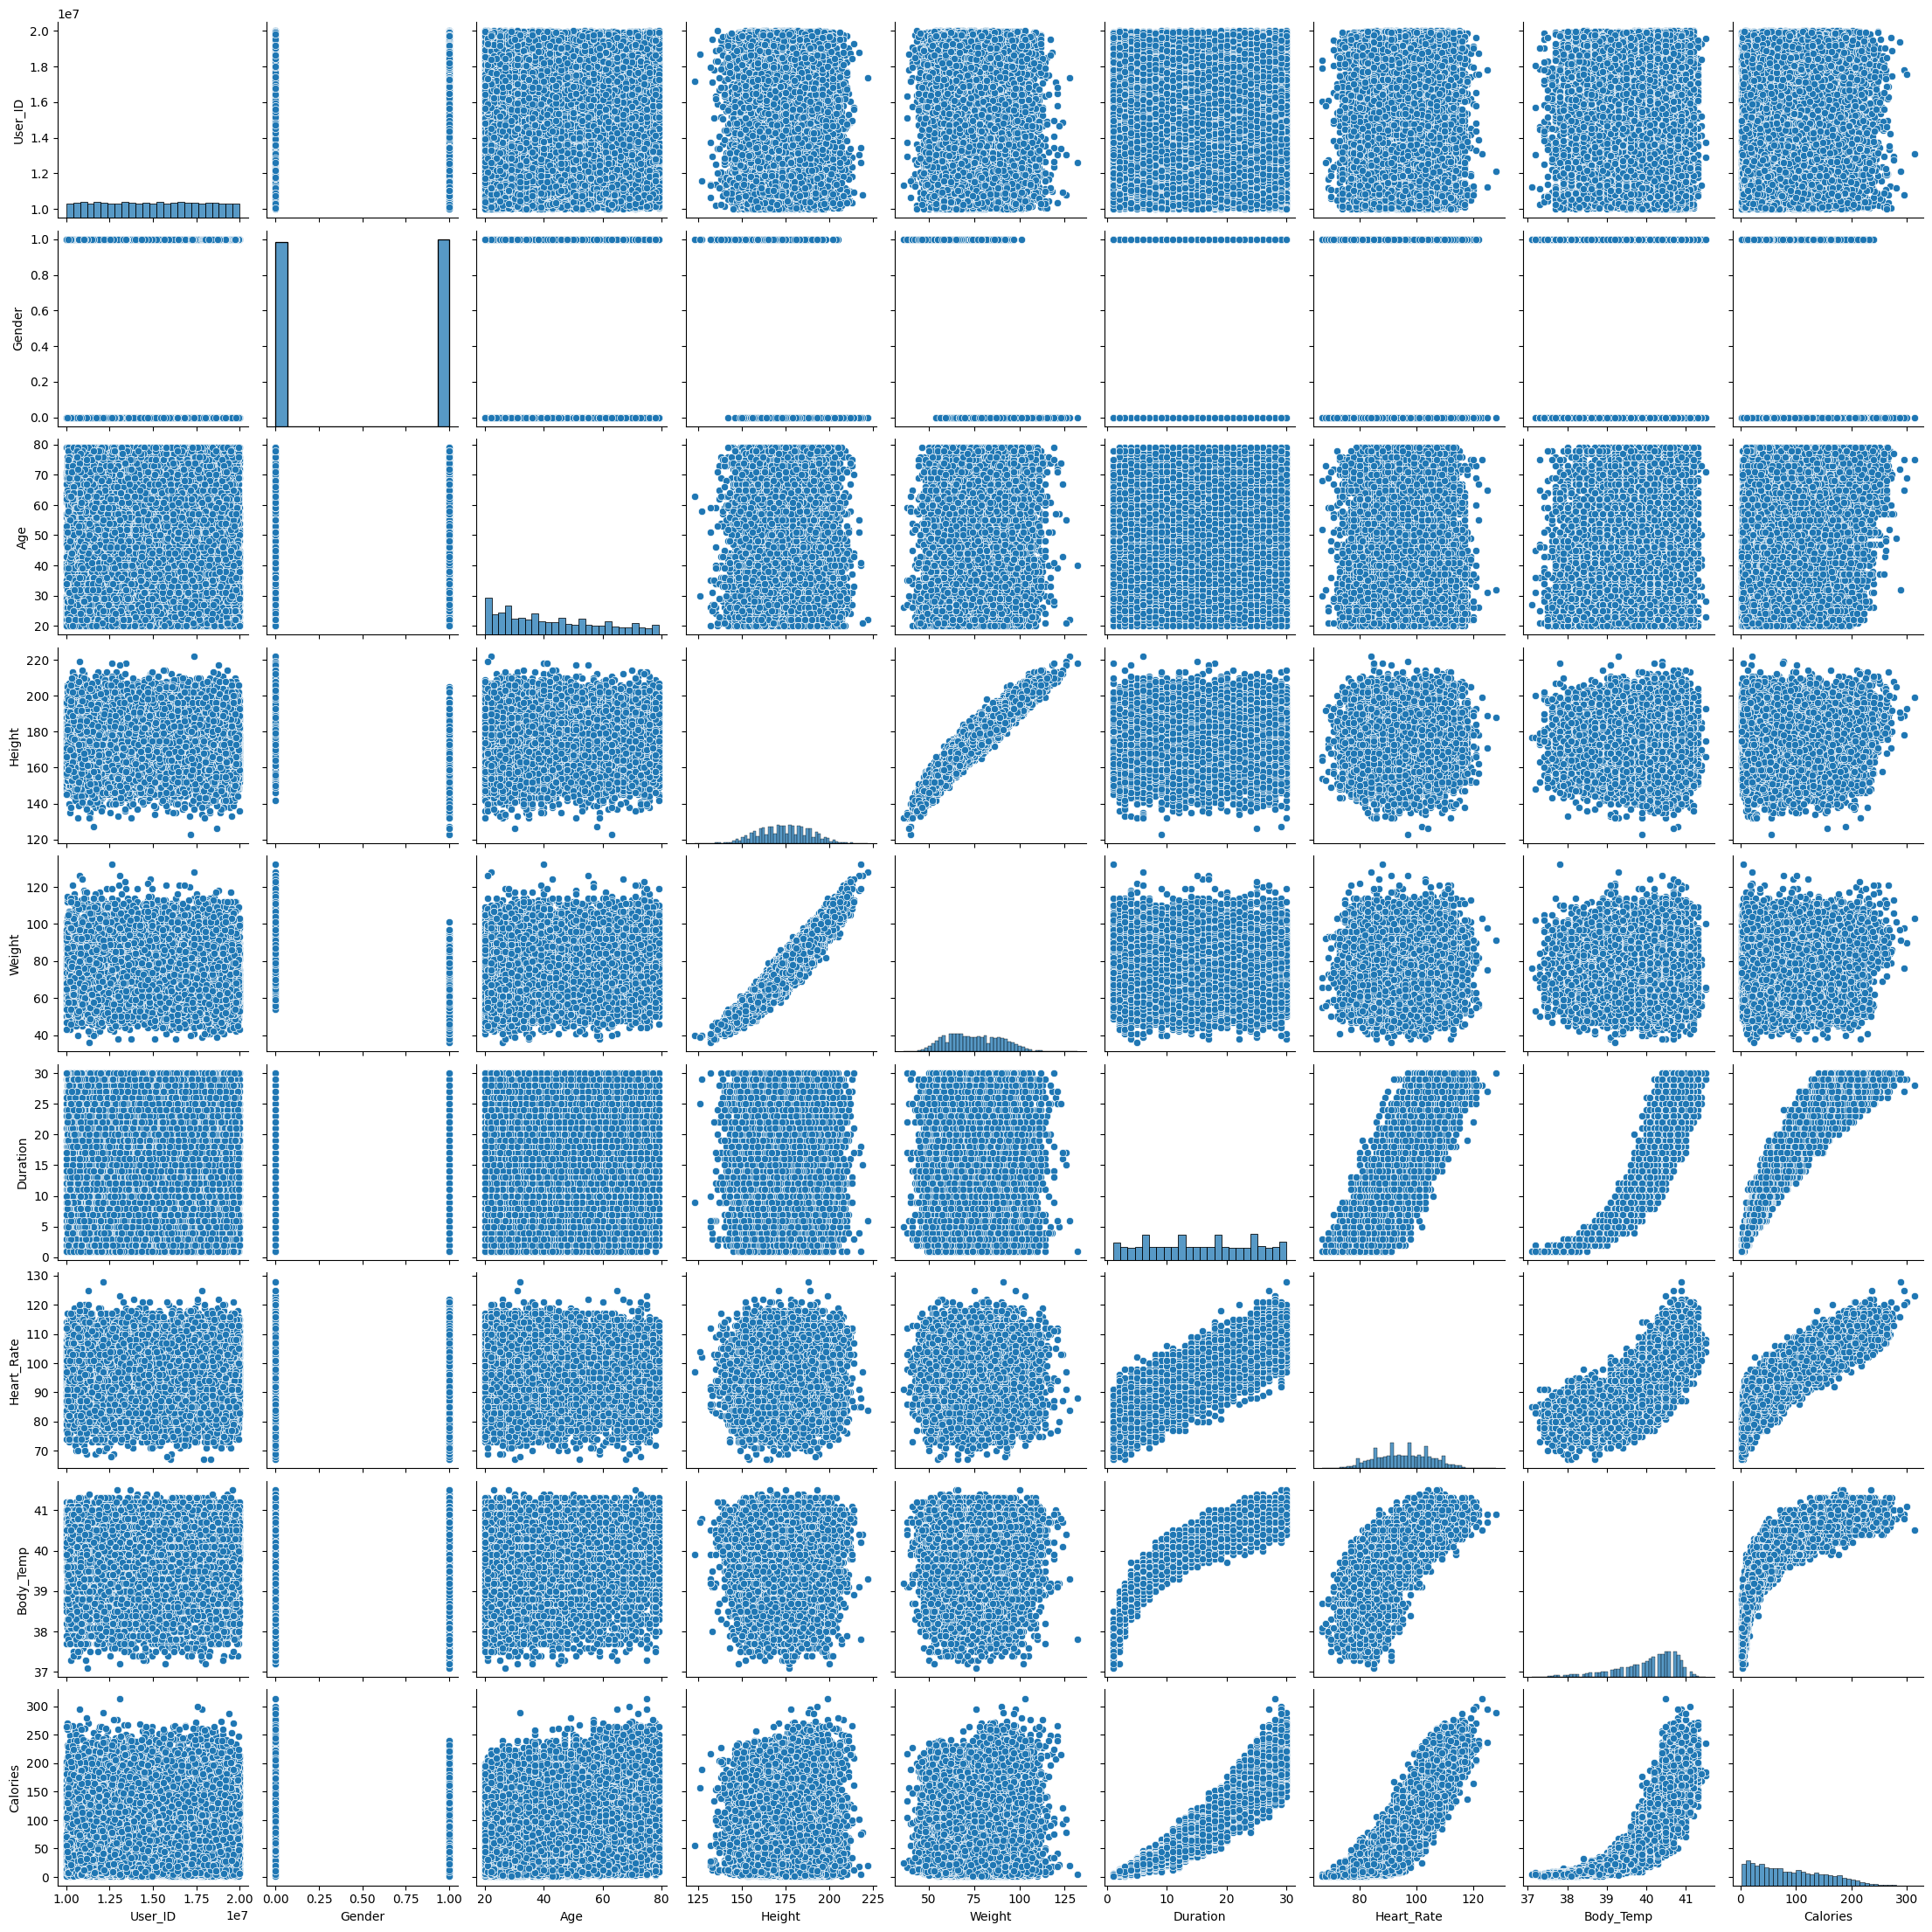

In [19]:
#Visualizing the data
sns.pairplot(calorie_data)
plt.show()

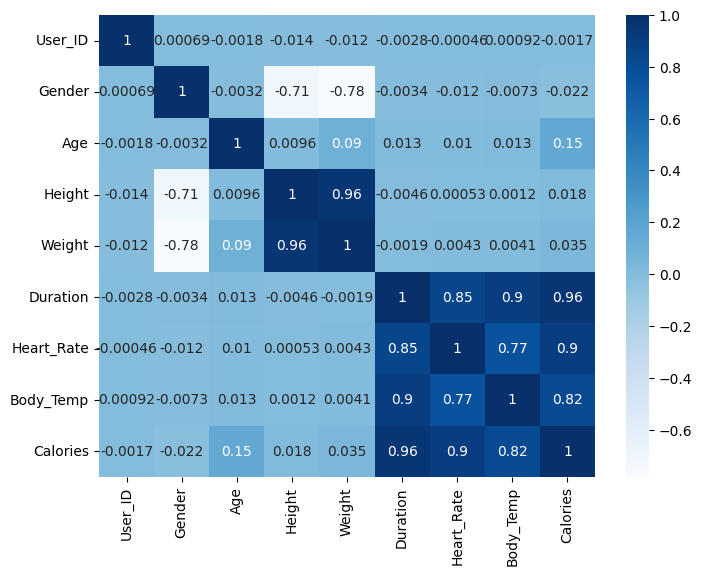

In [20]:
#correlation matrix
correlation = calorie_data.corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.show()

In [21]:
X=calorie_data.drop(columns=['User_ID','Calories','Gender'], axis=1)
Y=calorie_data['Calories']


In [22]:
#standard scaling the data of X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X=scaler.fit_transform(X)

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print(X.shape, X_train.shape, X_test.shape)

(15000, 6) (12000, 6) (3000, 6)


In [28]:
print(Y)

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64


In [24]:
#training the model on liner regression and svm
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
lr = LinearRegression()
svr = SVR()
lr.fit(X_train, Y_train)
svr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)
Y_pred_svr = svr.predict(X_test)


In [25]:
#comparing the accuracy of both the models
from sklearn.metrics import r2_score
r2_lr = r2_score(Y_test, Y_pred_lr)
r2_svr = r2_score(Y_test, Y_pred_svr)
print("R2 score of Linear Regression:", r2_lr)
print("R2 score of Support Vector Regression:", r2_svr)

R2 score of Linear Regression: 0.9668835512458388
R2 score of Support Vector Regression: 0.9869476024893942


In [27]:
#based on SVM model predicting the calories burnt
# input_data should have 6 features: Age, Height, Weight, Duration, Heart_Rate, Body_Temp
input_data = (25, 180, 70, 150, 1, 30)
#changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)
#reshaping the numpy array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
#standardizing the input data
std_data = scaler.transform(input_data_reshaped)
prediction = svr.predict(std_data)
print("The calories burnt is:", prediction[0])


The calories burnt is: 83.76335610951416


c:\Users\adelz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:
#save the SVM model and scaler using pickle
import pickle
filename = 'calorie_burnt_model.sav'
pickle.dump(svr, open(filename, 'wb'))
#save the scaler
scaler_filename = 'scaler.sav'
pickle.dump(scaler, open(scaler_filename, 'wb'))